#Business Question
* Which team spent the most this season?

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_excel('/content/drive/MyDrive/Project_2/TATA-IPL-2025-Auction-Final-List-cleaned.xlsx')

In [3]:
df.head()

,full name,Country,State Association,National/International,Age,Age Group,2024 Team,C/U,Team,Type,Base,Sold,Category
0,Jos Buttler,England,International,International,34,30-35,RR,Capped,GT,BAT,2,15.75,Auctioned
1,Shreyas Iyer,India,MCA,National,30,30-35,KKR,Capped,PBKS,BAT,2,26.75,Auctioned
2,Rishabh Pant,India,DDCA,National,27,25-30,DC,Capped,LSG,BAT,2,27.00,Auctioned
3,Kagiso Rabada,South Africa,International,International,29,25-30,PBKS,Capped,GT,BOWL,2,10.75,Auctioned
4,Arshdeep Singh,India,PCA,National,26,25-30,PBKS,Capped,PBKS,BOWL,2,18.00,Auctioned


##1. Team Spending Summary

In [4]:
team_summary = (
    df.groupby("Team")
      .agg(
          Total_Spend=("Sold", "sum"),
          Players_Bought=("full name", "count"),
          Avg_Price=("Sold", "mean")
      )
      .sort_values("Total_Spend", ascending=False)
      .reset_index()
)

team_summary

,Team,Total_Spend,Players_Bought,Avg_Price
0,CSK,119.95,25,4.798000
1,GT,119.85,25,4.794000
2,SRH,119.80,20,5.990000
3,MI,119.80,23,5.208696
4,RR,119.70,20,5.985000
5,PBKS,119.65,25,4.786000
6,LSG,119.60,23,5.200000
7,RCB,119.25,22,5.420455
8,DC,116.55,23,5.067391
9,KKR,107.95,21,5.140476


###Total Spend by Team

<Figure size 1000x600 with 0 Axes>

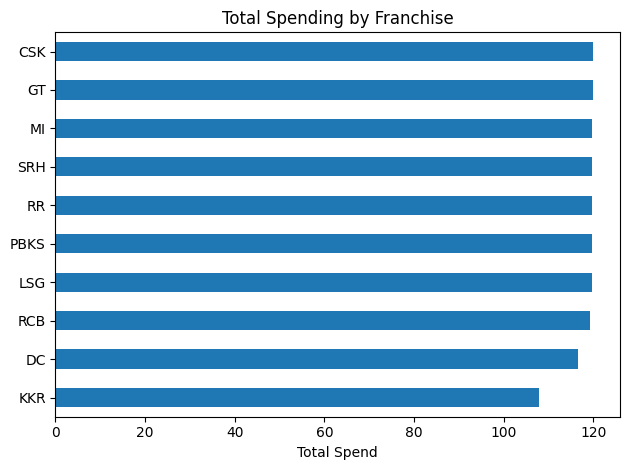

In [5]:
plt.figure(figsize=(10,6))

team_summary.sort_values("Total_Spend").plot(
    x="Team",
    y="Total_Spend",
    kind="barh",
    legend=False
)

plt.title("Total Spending by Franchise")
plt.xlabel("Total Spend")
plt.ylabel("")
plt.tight_layout()
plt.show()

**Insight:**

**CSK** was the highest spender (**119.95 Cr**), closely followed by **GT (119.85 Cr)** and **SRH/MI (119.80 Cr)**. **KKR** spent the least (**107.95 Cr**), suggesting a more conservative auction strategy.

###Team Strategy

In [12]:
!pip install adjustText -q

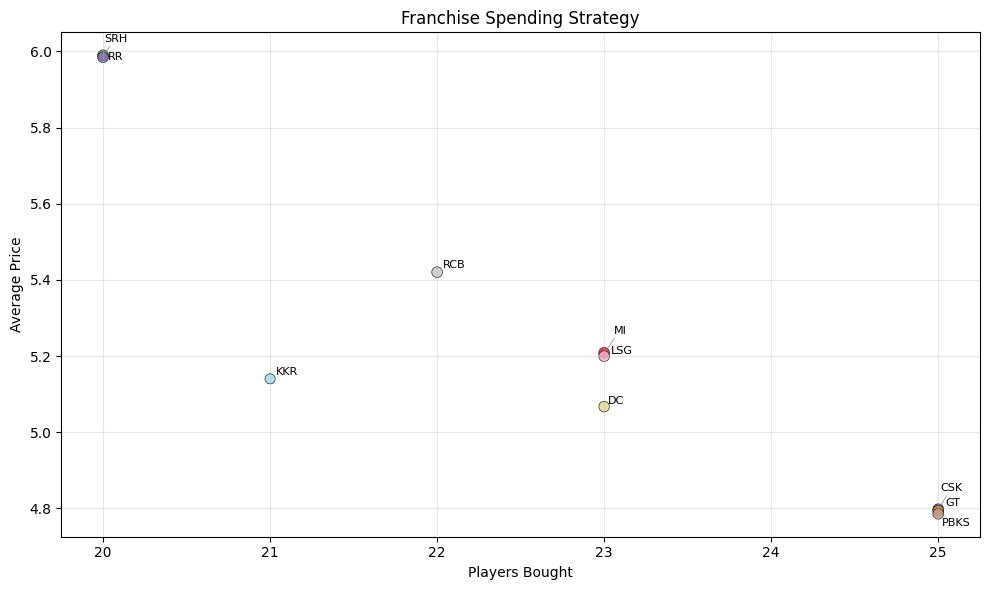

In [14]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from adjustText import adjust_text

plt.figure(figsize=(10, 6))

colors = cm.tab20(np.linspace(0, 1, len(team_summary)))

plt.scatter(
    team_summary["Players_Bought"],
    team_summary["Avg_Price"],
    s=team_summary["Total_Spend"] / 2,
    c=colors,
    alpha=0.8,
    edgecolors="black",
    linewidth=0.5
)


texts = []
for i, row in team_summary.iterrows():
    texts.append(
        plt.text(row["Players_Bought"], row["Avg_Price"], row["Team"], fontsize=8)
    )


adjust_text(
    texts,
    arrowprops=dict(arrowstyle="-", color="gray", lw=0.5),
    expand=(1.2, 1.4)
)

plt.xlabel("Players Bought")
plt.ylabel("Average Price")
plt.title("Franchise Spending Strategy")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**

**SRH (5.99 Cr)** and **RR (5.98 Cr)** recorded the highest average spending per player while purchasing only **20 players**, indicating a premium-player strategy. In contrast, **CSK, GT, and PBKS** acquired **25 players** with an average spend below **4.8 Cr**, reflecting a focus on squad depth and balanced investments.

##2. Spending Concentration
* Did the team spread money across players or spend heavily on a few?

In [7]:
top3_spend = (
    df.sort_values("Sold", ascending=False)
      .groupby("Team")
      .head(3)
      .groupby("Team")["Sold"]
      .sum()
)

team_summary["Top3_Spend"] = team_summary["Team"].map(top3_spend)

team_summary["Top3_%"] = (
    team_summary["Top3_Spend"] /
    team_summary["Total_Spend"]
) * 100

team_summary

,Team,Total_Spend,Players_Bought,Avg_Price,Top3_Spend,Top3_%
0,CSK,119.95,25,4.798000,49.00,40.850354
1,GT,119.85,25,4.794000,50.25,41.927409
2,SRH,119.80,20,5.990000,55.00,45.909850
3,MI,119.80,23,5.208696,50.70,42.320534
4,RR,119.70,20,5.985000,50.00,41.771094
5,PBKS,119.65,25,4.786000,62.75,52.444630
6,LSG,119.60,23,5.200000,59.00,49.331104
7,RCB,119.25,22,5.420455,45.00,37.735849
8,DC,116.55,23,5.067391,43.75,37.537538
9,KKR,107.95,21,5.140476,48.75,45.159796


###Top 3 Spending %

<Figure size 1000x600 with 0 Axes>

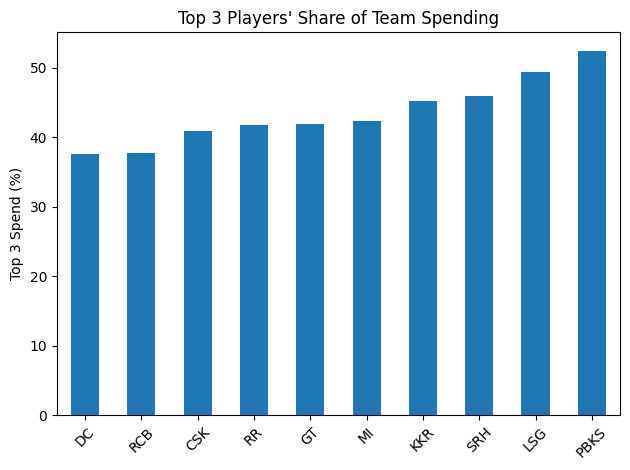

In [8]:
plt.figure(figsize=(10,6))

team_summary.sort_values("Top3_%").plot(
    x="Team",
    y="Top3_%",
    kind="bar",
    legend=False
)

plt.title("Top 3 Players' Share of Team Spending")
plt.xlabel("")
plt.ylabel("Top 3 Spend (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight:**

**PBKS** showed the highest spending concentration, investing **52.4%** of its total budget in just three players, followed by **LSG (49.3%)**. On the other hand, **DC (37.5%)** and **RCB (37.7%)** spread their budget more evenly across the squad, reducing reliance on a few marquee signings.

### Overall Business Insight

Most franchises utilized nearly the entire auction budget, with total spending ranging from **107.95 Cr (KKR)** to **119.95 Cr (CSK)**, indicating a highly competitive auction. However, spending strategies differed significantly. **PBKS** allocated **52.4%** of its total budget to just three players (**Shreyas Iyer**), reflecting a star-player acquisition strategy, while **DC (37.5%)** and **RCB (37.7%)** distributed spending more evenly across the squad, indicating a balanced team-building approach.